# Basic Imports

In [4]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
housing = datasets.fetch_california_housing(as_frame = True)

In [8]:
x_reg, y_reg = housing.data, housing.target
print(f"Data : \n{x_reg}")
print(f"\nTargets : \n{y_reg}")

Data : 
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -12

In [9]:
print(x_reg.shape)
print(y_reg.shape)

(20640, 8)
(20640,)


In [10]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

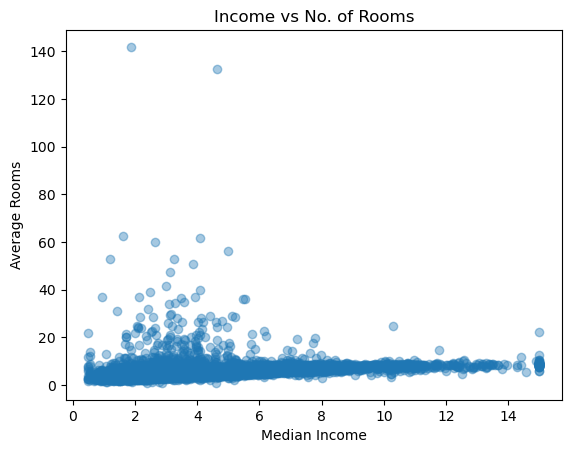

In [11]:
plt.scatter(housing.data['MedInc'], housing.data['AveRooms'], alpha=0.4)
plt.title("Income vs No. of Rooms")
plt.xlabel("Median Income")
plt.ylabel("Average Rooms")
plt.plot()
plt.show()

<br>
<br>
<br>


# Regression Model

In [12]:
from sklearn.model_selection import train_test_split

In [16]:
X = housing.data
Y = housing.target

In [17]:
# Random state = constant for same results every run, remove later
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=50) 

In [18]:
print(f"Total dataset: {X.shape[0]} rows")
print(f"Training set:  {XTrain.shape[0]} rows")
print(f"Testing set:   {XTest.shape[0]} rows")

Total dataset: 20640 rows
Training set:  16512 rows
Testing set:   4128 rows


In [19]:
xTrain = XTrain.values
yTrain = YTrain.values

nSamples = xTrain.shape[0]
nFeatures = xTrain.shape[1]

In [20]:
# z = (x-mu)/sigma

mean = np.mean(xTrain, axis=0)
std = np.std(xTrain, axis=0)

xTrainScaled = (xTrain - mean) / std

In [21]:
# y = wx + b

w = np.zeros(nFeatures)
b = 0.0

In [22]:
learningRate = 0.01
epochs = 1000

In [23]:
# Training

print(f"\nStaring Training\n")

for epoch in range(epochs):

    # predicted_y = weight * x + b
    yPred = np.dot(xTrainScaled, w) + b

    # error = predicted_y - target_y
    error = yPred - yTrain

    # Gradient calculation
    # dy/dx : dw/db

    dw = (2 / nSamples) * np.dot(xTrainScaled.T, error)
    db = (2 / nSamples) * np.sum(error)

    # Updating w and b
    w -= learningRate * dw
    b -= learningRate * db

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        mse = np.mean(error ** 2)
        print(f"Epoch {epoch + 1:4} | Mean Squared Error: {mse:.4f}")

print("\n--- Training Complete ---")
print("Learned Weights:", np.round(w, 4))
print("Learned Bias:   ", round(b, 4))


Staring Training

Epoch  100 | Mean Squared Error: 0.7174
Epoch  200 | Mean Squared Error: 0.6012
Epoch  300 | Mean Squared Error: 0.5805
Epoch  400 | Mean Squared Error: 0.5666
Epoch  500 | Mean Squared Error: 0.5564
Epoch  600 | Mean Squared Error: 0.5489
Epoch  700 | Mean Squared Error: 0.5434
Epoch  800 | Mean Squared Error: 0.5394
Epoch  900 | Mean Squared Error: 0.5364
Epoch 1000 | Mean Squared Error: 0.5341

--- Training Complete ---
Learned Weights: [ 0.8336  0.1446 -0.2218  0.2499  0.0028 -0.0474 -0.6901 -0.6546]
Learned Bias:    2.0662


In [24]:
# Evaluation

xTest = XTest.values
yTest = YTest.values

xTestScaled = (xTest - mean) / std

# y = wx + b 
yPredictionAfterTraining = np.dot(xTestScaled, w) + b

testError = yPredictionAfterTraining - yTest
testMeanSquareError = np.mean(testError ** 2)

# D. Calculate R-squared (R2) Score
ss_total = np.sum((yTest - np.mean(yTest)) ** 2)
ss_residual = np.sum(testError ** 2)
r2_score = 1 - (ss_residual / ss_total)

print(f"\n--- Test Set Performance ---")
print(f"Test Mean Squared Error (MSE): {testMeanSquareError:.4f}")
print(f"Test Root Mean Squared Error:  {np.sqrt(testMeanSquareError):.4f}")
print(f"R-squared (R2) Score:          {r2_score:.4f}")


--- Test Set Performance ---
Test Mean Squared Error (MSE): 0.5195
Test Root Mean Squared Error:  0.7208
R-squared (R2) Score:          0.6001


In [25]:
# --- 4. PREDICTING A CUSTOM HOUSE ---

# Create a custom house. 
# The features MUST be in this exact order: 
# [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]

# Let's invent a house:
# Income: 6.5 (representing $65,000)
# Age: 15 years
# Rooms: 5.5 (Average)
# Bedrooms: 1.2 (Average)
# Population: 1200 people in the block
# Occupancy: 3.0 people per house
# Latitude/Longitude: 36.0, -119.0 (Central California)

customHouse = np.array([[6.5, 15.0, 5.5, 1.2, 1200.0, 3.0, 36.0, -119.0]])

# A. Scale the custom features using the TRAINING mean and std
customHouseScaled = (customHouse - mean) / std

# B. Make the prediction (dot product of scaled features and weights, plus bias)
predictedValue = np.dot(customHouseScaled, w) + b

# C. Interpret the result
# The California Housing dataset stores target values in hundreds of thousands of dollars.
# So a prediction of 2.5 equals $250,000.
predictedPriceInDollars = predictedValue[0] * 100000

print(f"\n--- Custom House Prediction ---")
print(f"Raw Model Output:      {predictedValue[0]:.4f}")
print(f"Estimated House Price: ${predictedPriceInDollars:,.2f}")


--- Custom House Prediction ---
Raw Model Output:      2.8045
Estimated House Price: $280,454.98


<br>
<br>
<br>

# Desicion Tree

In [54]:
class DecisionTree:

    def __init__(self, maxDepth=3):
        self.maxDepth = maxDepth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._buildTree(X, y, depth=0)

    def _buildTree(self, X, y, depth):
        nSamples, nFeatures = X.shape

        # Base case
        if depth >= self.maxDepth or nSamples <= 1:
            return {"value" : np.mean(y)}

        # To track the best splits
        bestFeature = None
        bestThreshold = None
        bestVarianceReduction = -1

        # Finding the best splits
        for featureIdx in range(nFeatures):
            featureCol = X[:, featureIdx] 

            min = np.min(featureCol)
            max = np.max(featureCol)
            thresholds = np.linspace(min, max, 10)

            for threshold in thresholds:
                leftMask = featureCol <= threshold
                rightMask = ~leftMask # featureCol > threshold

                if(np.sum(leftMask) == 0 or np.sum(rightMask) == 0):
                    continue

                varianceReduction = self._calculateVarianceReduction(y, y[leftMask], y[rightMask])

                if varianceReduction > bestVarianceReduction:
                    bestVarianceReduction = varianceReduction
                    bestThreshold = threshold
                    bestFeature = featureIdx

        if bestVarianceReduction <= 0:
            return {"value" : np.mean(y)}

        leftMask = X[:, bestFeature] <= bestThreshold
        rightMask = ~leftMask

        leftBranch = self._buildTree(X[leftMask], y[leftMask], depth + 1)
        rightBranch = self._buildTree(X[rightMask], y[rightMask], depth + 1)

        return {
            "feature" : bestFeature,
            "threshold" : bestThreshold,
            "left" : leftBranch, 
            "right" : rightBranch 
        }

    
    def _calculateVarianceReduction(self, parentY, leftY, rightY):

        parentVar = np.var(parentY)
        leftVar = np.var(leftY)
        rightVar = np.var(rightY)

        totalNumber = len(parentY)

        wLeft = len(leftY) / totalNumber
        wRight = len(rightY) / totalNumber

        return parentVar - ((wLeft * leftVar) + (wRight * rightVar))

    def predict(self, X):
        # Create an array to store our predictions
        predictions = []
        
        # Pass each house (row) through the tree one by one
        for x in X:
            pred = self._traverseTree(x, self.tree)
            predictions.append(pred)
            
        return np.array(predictions)

    def _traverseTree(self, x, node):
        # --- 1. BASE CASE (Leaf Node) ---
        # If the dictionary has a "value" key, we reached the end of the branch!
        if "value" in node:
            return node["value"]

        # --- 2. THE QUESTION ---
        # Look up the specific feature for this house
        feature_value = x[node["feature"]]

        # --- 3. THE SPLIT ---
        # If the feature is <= the threshold, go down the left branch.
        if feature_value <= node["threshold"]:
            return self._traverseTree(x, node["left"])
        # Otherwise, go down the right branch.
        else:
            return self._traverseTree(x, node["right"])

In [55]:
# Training
#  use the raw xTrain, not the scaled version
treeModel = DecisionTree(maxDepth=3)
print("\nGrowing Decision Tree...")
treeModel.fit(xTrain, yTrain)
print("Tree successfully grown!")


Growing Decision Tree...
Tree successfully grown!


In [65]:
# 1. Initialize and train the model (if you haven't already)
tree_model = DecisionTree(maxDepth=20)
print("Training Tree...")
tree_model.fit(xTrain, yTrain)

# 2. Make predictions on the unscaled test set
print("Making Predictions...")
tree_y_pred = tree_model.predict(xTest)

# 3. Calculate Metrics
tree_mse = np.mean((tree_y_pred - yTest) ** 2)

ssTotal = np.sum((yTest - np.mean(yTest)) ** 2)
ssResidual = np.sum((tree_y_pred - yTest) ** 2)
tree_r2 = 1 - (ssResidual / ssTotal)

print(f"\n--- Decision Tree (Depth 3) Performance ---")
print(f"Test Mean Squared Error (MSE): {tree_mse:.4f}")
print(f"R-squared (R2) Score:          {tree_r2:.4f}")

Training Tree...
Making Predictions...

--- Decision Tree (Depth 3) Performance ---
Test Mean Squared Error (MSE): 0.5536
R-squared (R2) Score:          0.5739


<br>
<br>
<br>

# Neural Network

In [73]:
yTrainMat = yTrain.reshape(-1, 1)

inputSize = nFeatures
hiddenSize = 32                  # hidden layer nodes / neurons
outputSize = 1

# We have 3 layers
# input[8] --> hidden[32] --> output[1]
# each link has own weight and bias
# input --(w1, b1)--> hidden --(w2, b2)--> output

w1 = np.random.randn(inputSize, hiddenSize) * 0.1
b1 = np.zeros( (1, hiddenSize) ) # passing a tuple

w2 = np.random.randn(hiddenSize, outputSize) * 0.1
b2 = np.zeros( (1, outputSize) ) # passing a tuple

learningRate = 0.01
epochs = 2000

xTrainScaled = xTrainScaled # written so i dont forget it exists
nSamples = xTrainScaled.shape[0]

print(f"Training Neural Network")

for epoch in range(epochs):

    """ Forward Pass """
    # y = w*x + b
    linearOutputLayer1 = np.dot(xTrainScaled, w1) + b1
    # Activation functions : ReLU, GeLU, tanh, sigmoid, Leaky ReLU
    activatedOutputLayer1 = np.maximum(0, linearOutputLayer1) # ReLU {x such that x > 0 = x, x < 0 = 0}

    linearOutputLayer2 = np.dot(activatedOutputLayer1, w2) + b2
    # ReLU, or any activation funtion is not applied to the 
    # last layer to keep the "predictions" intact
    # Ex : if prices are being predicted,
    # if a -ve price is predicted, 
    # ReLU will squah that to 0, and
    # the model wont learn that it was wrong.
    # Leaving the values as-is, allows the Loss Function
    # to do its job and also helps improving backpropogation

    """ Error Calculation """
    predictionError = linearOutputLayer2 - yTrainMat

    
    """ Backward Pass"""
    linearGradientLayer2 = (2 / nSamples) * predictionError

    # 
    weightGradientLayer2 = np.dot(activatedOutputLayer1.T, linearGradientLayer2)
    biasGradientLayer2 = np.sum(linearGradientLayer2, axis=0, keepdims=True)


    activationGradientLayer1 = np.dot(linearGradientLayer2, w2.T)
    linearGradientLayer1 = activationGradientLayer1 * (linearOutputLayer1 > 0) # derivative of ReLU
    # ReLU      = {0, x < 0; x, x > 0}
    # d/dx ReLU = {0, x < 0; 1, x > 0}
    # here, x = linearOutputLayer1

    weightGradientLayer1 = np.dot(xTrainScaled.T, linearGradientLayer1)
    biasGradientLayer1 = np.sum(linearGradientLayer1, axis=0, keepdims=True)


    """ Updating weights and biases """
    w1 -= learningRate * weightGradientLayer1 
    b1 -= learningRate * biasGradientLayer1 
    
    w2 -= learningRate * weightGradientLayer2 
    b1 -= learningRate * biasGradientLayer2

    if (epoch + 1) % 100 == 0:
        meanSquaredError = np.mean(predictionError ** 2)
        print(f"Epoch {epoch + 1:4} | Mean Squared Error: {meanSquaredError:.4f}")
    
    

Training Neural Network
Epoch  100 | Mean Squared Error: 0.6420
Epoch  200 | Mean Squared Error: 0.5930
Epoch  300 | Mean Squared Error: 0.5663
Epoch  400 | Mean Squared Error: 0.5461
Epoch  500 | Mean Squared Error: 0.5305
Epoch  600 | Mean Squared Error: 0.5185
Epoch  700 | Mean Squared Error: 0.5089
Epoch  800 | Mean Squared Error: 0.5011
Epoch  900 | Mean Squared Error: 0.4946
Epoch 1000 | Mean Squared Error: 0.4888
Epoch 1100 | Mean Squared Error: 0.4838
Epoch 1200 | Mean Squared Error: 0.4794
Epoch 1300 | Mean Squared Error: 0.4752
Epoch 1400 | Mean Squared Error: 0.4713
Epoch 1500 | Mean Squared Error: 0.4679
Epoch 1600 | Mean Squared Error: 0.4646
Epoch 1700 | Mean Squared Error: 0.4616
Epoch 1800 | Mean Squared Error: 0.4588
Epoch 1900 | Mean Squared Error: 0.4562
Epoch 2000 | Mean Squared Error: 0.4538


In [77]:
# --- EVALUATION ON TEST SET ---

# 1. Prepare the test data
# Use the 'mean' and 'std' calculated earlier strictly from the training set
testFeatures = xTest
scaledTestFeatures = (testFeatures - mean) / std

# Reshape test targets to match the (N, 1) matrix shape of the predictions
testTargetMatrix = yTest.reshape(-1, 1)

# 2. Forward Pass on Test Data (No backward pass / training here!)
linearOutputLayer1Test = np.dot(scaledTestFeatures, w1) + b1
activatedOutputLayer1Test = np.maximum(0, linearOutputLayer1Test)
testPredictedPrices = np.dot(activatedOutputLayer1Test, w2) + b2

# 3. Calculate Error
testPredictionError = testPredictedPrices - testTargetMatrix
testMeanSquaredError = np.mean(testPredictionError ** 2)

# 4. Calculate R-squared (R2) Score
sumOfSquaresTotal = np.sum((testTargetMatrix - np.mean(testTargetMatrix)) ** 2)
sumOfSquaresResidual = np.sum(testPredictionError ** 2)
r2Score = 1 - (sumOfSquaresResidual / sumOfSquaresTotal)

print("\n--- Neural Network Test Performance ---")
print(f"Test Mean Squared Error (MSE): {testMeanSquaredError:.4f}")
print(f"Test Root Mean Squared Error:  {np.sqrt(testMeanSquaredError):.4f}")
print(f"R-squared (R2) Score:          {r2Score:.4f}")


--- Neural Network Test Performance ---
Test Mean Squared Error (MSE): 0.4527
Test Root Mean Squared Error:  0.6728
R-squared (R2) Score:          0.6515
